# Scat-to-Bass Final Demo

Upload or select a vocal recording, choose an articulation knob, then run the cached-DCT Bass-DDSP pipeline. Leave about 500 ms of ambient noise at the beginning so the causal noise gate can calibrate itself.

In [ ]:
from pathlib import Path
import sys

WORKSPACE = Path('/workspace')
if str(WORKSPACE) not in sys.path:
    sys.path.insert(0, str(WORKSPACE))

from IPython.display import Audio, display
import ipywidgets as widgets
import matplotlib.pyplot as plt

from demo import DemoConfig, ScatToBassDemo
from demo.visualization import plot_demo_result
from vocal_controls import display_upload_widget, list_audio_inputs

UPLOAD_DIR = WORKSPACE / 'demo' / 'uploads'
UPLOAD_DIR.mkdir(parents=True, exist_ok=True)
display_upload_widget(UPLOAD_DIR)

After the upload widget says **Saved**, run the next cell. You may instead put an absolute path in `AUDIO_PATH`. Choose an octave from -2 to +2; 0 sends detected F0 directly to Bass-DDSP. `Slap auto` latches `ST_NO` below MIDI 40 and `SP_NO` at or above MIDI 40 for each detected note.

In [31]:
AUDIO_PATH = None  # Example: '/workspace/learn/voice_inputs/Scat 5.m4a'
PITCH_SHIFT_SEMITONES = 0.0
SLAP_CROSSOVER_MIDI = 40

articulation_knob = widgets.Dropdown(
    options=['Slap auto', 'FS_NO', 'MU_NO', 'PK_NO', 'SP_NO', 'ST_NO', 'FS_DN'],
    value='Slap auto',
    description='Style:',
)
octave_knob = widgets.IntSlider(
    value=0,
    min=-2,
    max=2,
    step=1,
    description='Octave:',
    continuous_update=False,
)
display(widgets.HBox([articulation_knob, octave_knob]))

Dropdown(description='Style:', options=('Slap auto', 'FS_NO', 'MU_NO', 'PK_NO', 'SP_NO', 'ST_NO', 'FS_DN'), va…

In [41]:
config = DemoConfig(
    device='auto',
    pitch_shift_semitones=PITCH_SHIFT_SEMITONES,
    slap_crossover_midi=SLAP_CROSSOVER_MIDI,
)
engine = ScatToBassDemo(config)
print('Loaded on', engine.device)
print('Cached DCT bank:', tuple(engine.cached_dct_bank.shape))
print('One-time setup:', {key: f'{value:.3f} s' for key, value in engine.setup_times.items()})

Loaded on cuda:5
Cached DCT bank: (6, 4800)
One-time setup: {'load_bass_model_seconds': '0.117 s', 'cache_dct_bank_seconds': '0.000 s', 'load_onset_model_seconds': '0.002 s'}


In [42]:
if AUDIO_PATH is None:
    uploaded = list_audio_inputs(UPLOAD_DIR)
    if not uploaded:
        raise FileNotFoundError('Upload an audio file above or set AUDIO_PATH.')
    selected_audio = uploaded[0]
else:
    selected_audio = Path(AUDIO_PATH).expanduser()

print('Input:', selected_audio)
result = engine.run(
    selected_audio,
    articulation_mode=articulation_knob.value,
    octave_shift=octave_knob.value,
)

# Wall-clock processing and estimated causal detector latency are printed
# immediately after reconstruction, as distinct measurements.
engine.print_timing(result)

print('\nVocal input')
display(Audio(result['audio'], rate=result['sample_rate']))
print('Bass reconstruction')
display(Audio(result['listen_audio'], rate=result['sample_rate']))

Input: /workspace/demo/uploads/Scat 8.m4a
Device: cuda:5; cached DCT bank: yes
Audio duration: 9.472 s
Observed processing: controls 0.286 s | mapping 0.020 s | synthesis 0.013 s (RTF 0.001) | total 0.380 s (RTF 0.040)
Algorithmic timing: 32 ms frame, 16 ms hop, aubio onset median 56.7 ms, max 65.4 ms; parallel-path bound about 65.4 ms
The algorithmic bound excludes microphone/audio-driver buffering. The wall times above are offline notebook measurements.
Output: /workspace/demo/outputs/Scat 8_20260729_134145_545259

Vocal input


Bass reconstruction


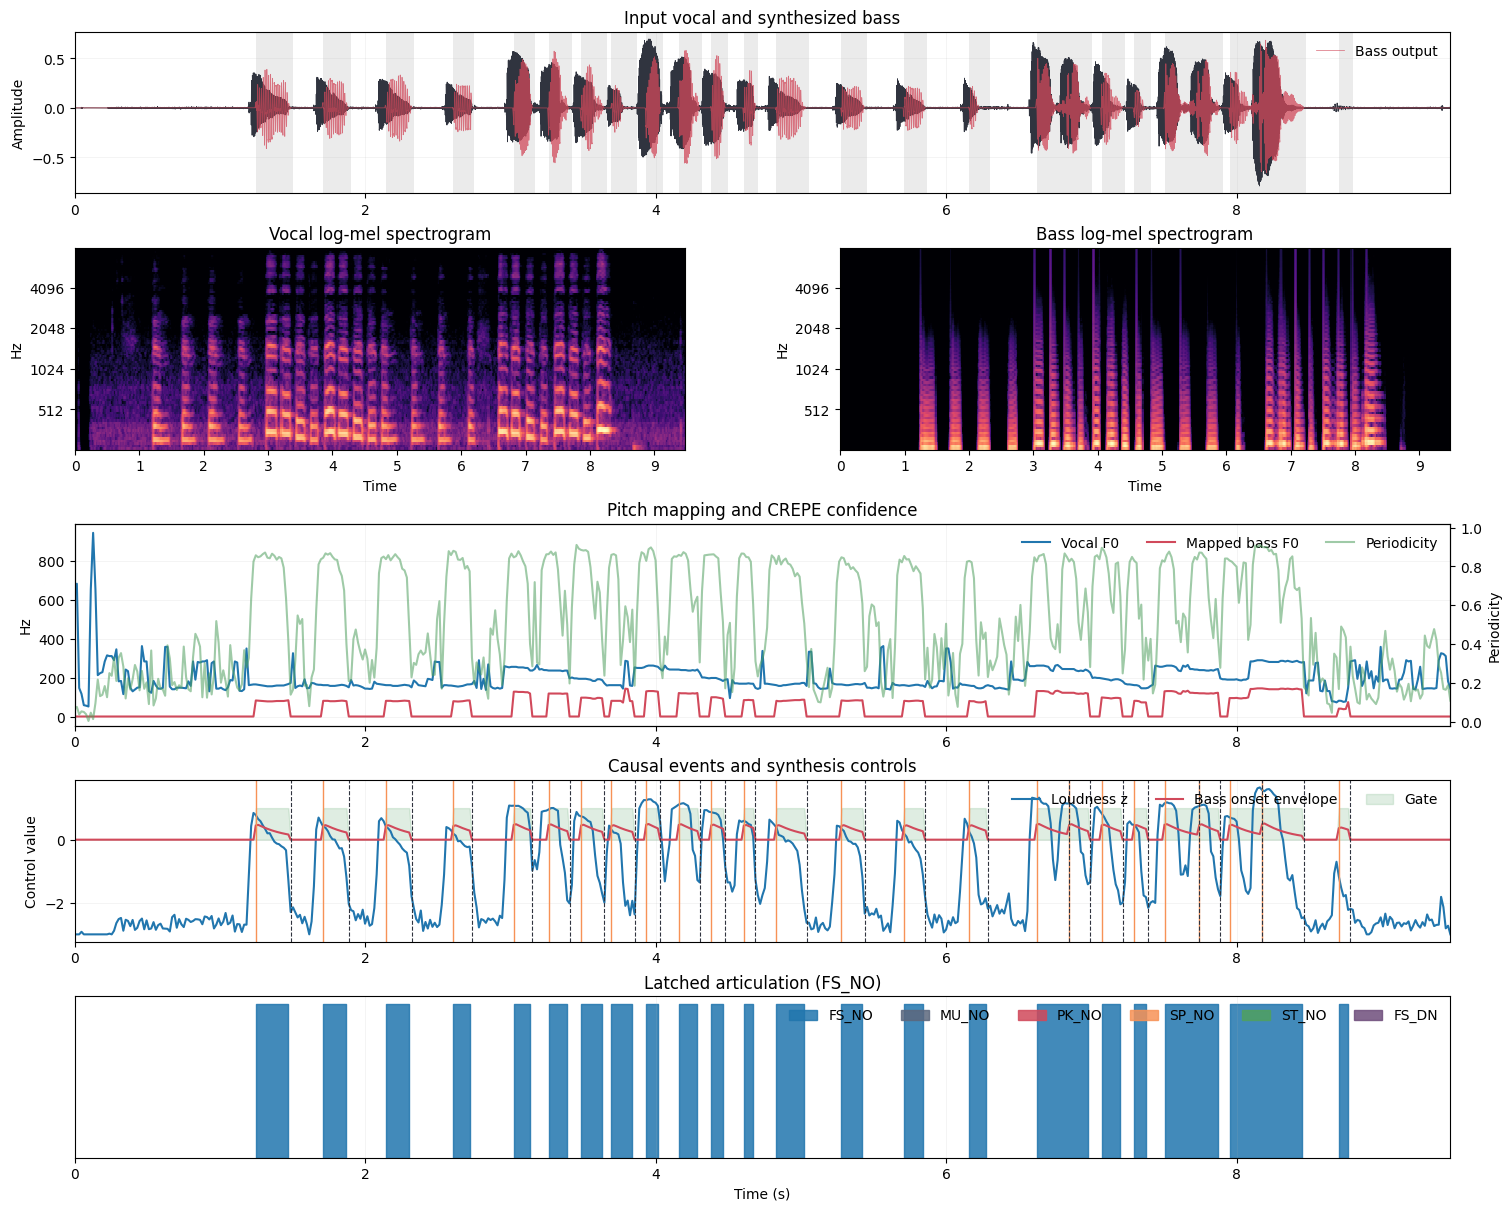

In [43]:
figure = plot_demo_result(result)
display(figure)
plt.close(figure)